# Optimisation Combinatoire — Recuit Simulé (Simulated Annealing)

## Introduction et objectif du projet

Ce projet fait partie d'un travail plus large sur l'optimisation combinatoire appliquée à la planification d'examens universitaires. Le problème posé est le suivant : étant donnés N examens à programmer sur P périodes, et une matrice de conflits qui indique combien d'étudiants sont inscrits à chaque paire d'examens, comment minimiser le stress des étudiants en espaçant le plus possible les examens auxquels ils sont inscrits ?

La fonction objectif à minimiser est :

**Z = Σ c_ij × w(|période_i - période_j|)**

où c_ij est le nombre d'étudiants communs entre les examens i et j, et w est un vecteur de pénalités qui diminue avec la distance entre les périodes. Plus deux examens conflictuels sont proches dans le planning, plus Z est élevé. L'objectif est de minimiser Z.

Ce problème est NP-difficile : il est impossible de tester toutes les combinaisons possibles pour des instances de grande taille. C'est pourquoi j'utilise ici le **Recuit Simulé**, une métaheuristique inspirée du processus physique de recuit des métaux, qui permet de trouver de bonnes solutions sans garantie d'optimalité globale.

## 1. Chargement des bibliothèques et des données

Le dataset est un fichier Excel avec trois feuilles : la matrice de conflits entre examens, le vecteur de poids selon la distance entre périodes, et le planning initial.

In [1]:
import pandas as pd
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import time
import tracemalloc

file_path = "C:/Users/LOQ/Desktop/data et son code/comp/projet_exam (1)/projet_exam/exam_scheduling_data_readable.xlsx"

df_conflict = pd.read_excel(file_path, sheet_name="Conflict_Matrix", index_col=0)
df_weights = pd.read_excel(file_path, sheet_name="Weights")
df_schedule = pd.read_excel(file_path, sheet_name="Schedule", index_col=0)

C = df_conflict.values
w = df_weights.values.flatten()
x_it = df_schedule.values

exam_periods = np.argmax(x_it, axis=1)
N = C.shape[0]
P = len(w)

## 2. Analyse exploratoire des données

### 2.1 Calcul de Z initial et identification des paires problématiques

Avant d'optimiser, je calcule le Z du planning actuel pour avoir une référence de départ. J'identifie également les paires d'examens qui contribuent le plus à Z, c'est-à-dire les examens les plus conflictuels qui sont mal espacés.

In [2]:
def compute_Z(periods, Cmat, wvec):
    Z = 0.0
    N = Cmat.shape[0]
    for i in range(N):
        for j in range(i+1, N):
            cij = Cmat[i,j]
            if cij == 0:
                continue
            diff = abs(int(periods[i]) - int(periods[j]))
            if diff < len(wvec):
                Z += cij * wvec[diff]
    return Z

Z_initial = compute_Z(exam_periods, C, w)
print(f"Z (planning actuel) = {Z_initial:.2f}")

pairs = []
for i in range(N):
    for j in range(i+1, N):
        cij = C[i,j]
        if cij == 0:
            continue
        diff = abs(int(exam_periods[i]) - int(exam_periods[j]))
        contrib = cij * (w[diff] if diff < len(w) else 0)
        if contrib > 0:
            pairs.append((contrib, i+1, j+1, cij, diff))

pairs_sorted = sorted(pairs, key=lambda x: x[0], reverse=True)
print("\nTop 20 paires contributrices (contrib, exam_i, exam_j, Cij, dist_period):")
for row in pairs_sorted[:20]:
    print(row)

Z (planning actuel) = 91116.00

Top 20 paires contributrices (contrib, exam_i, exam_j, Cij, dist_period):
(np.int64(50), 1, 11, np.int64(10), 2)
(np.int64(50), 1, 36, np.int64(10), 0)
(np.int64(50), 1, 91, np.int64(10), 2)
(np.int64(50), 2, 8, np.int64(10), 4)
(np.int64(50), 2, 33, np.int64(10), 2)
(np.int64(50), 2, 71, np.int64(10), 2)
(np.int64(50), 3, 14, np.int64(10), 2)
(np.int64(50), 3, 49, np.int64(10), 4)
(np.int64(50), 3, 60, np.int64(10), 2)
(np.int64(50), 3, 67, np.int64(10), 0)
(np.int64(50), 3, 83, np.int64(10), 2)
(np.int64(50), 4, 45, np.int64(10), 2)
(np.int64(50), 4, 63, np.int64(10), 2)
(np.int64(50), 4, 66, np.int64(10), 4)
(np.int64(50), 4, 78, np.int64(10), 0)
(np.int64(50), 4, 100, np.int64(10), 4)
(np.int64(50), 5, 18, np.int64(10), 2)
(np.int64(50), 5, 29, np.int64(10), 8)
(np.int64(50), 5, 30, np.int64(10), 2)
(np.int64(50), 5, 36, np.int64(10), 2)


### 2.2 Contribution par examen et répartition du planning

Je regarde quels examens contribuent le plus à Z et comment ils sont répartis sur les périodes.

In [3]:
contrib_per_exam = np.zeros(N)
for contrib, i, j, cij, diff in pairs:
    contrib_per_exam[i-1] += contrib
    contrib_per_exam[j-1] += contrib

top_exams = sorted([(contrib_per_exam[i], i+1) for i in range(N)], reverse=True)
print("Top 10 examens par contribution totale (contrib, exam):")
for val, ex in top_exams[:10]:
    print(f"Exam_{ex}: {val:.2f}")

counts = np.bincount(exam_periods, minlength=P)
print("\nNombre d'examens par période (index period 0..):", counts)

Top 10 examens par contribution totale (contrib, exam):
Exam_98: 2130.00
Exam_7: 2083.00
Exam_35: 2045.00
Exam_65: 2035.00
Exam_79: 2027.00
Exam_60: 2027.00
Exam_83: 1990.00
Exam_33: 1980.00
Exam_88: 1971.00
Exam_49: 1971.00

Nombre d'examens par période (index period 0..): [10 11  8 12 13 11  9 10  7  9]


## 3. Modélisation — Algorithme de Recuit Simulé

### 3.1 Principe

Le Recuit Simulé s'inspire du processus physique de refroidissement lent d'un métal : à haute température, les atomes bougent beaucoup et peuvent s'éloigner d'un minimum local. En refroidissant progressivement, ils se stabilisent dans une configuration de faible énergie.

En optimisation, cela se traduit par : à chaque itération, on génère un voisin (une petite modification du planning) et on décide si on l'accepte. Si le voisin est meilleur, on l'accepte toujours. S'il est moins bon, on l'accepte quand même avec une probabilité P = exp(-Δ/T) qui diminue avec la température T. Ce mécanisme permet d'éviter de rester bloquée dans un minimum local.

In [4]:
INITIAL_TEMP = 1000.0
COOLING_RATE = 0.95
ITERATIONS_PER_TEMP = 100
MIN_TEMP = 0.1

def get_neighbor(periods):
    neighbor = periods.copy()
    exam = random.randint(0, N-1)
    neighbor[exam] = random.randint(0, P-1)
    return neighbor

def fitness_periods(periods):
    return compute_Z(periods, C, w)

current_solution = exam_periods.tolist()
current_cost = fitness_periods(current_solution)
best_solution = current_solution.copy()
best_cost = current_cost
temperature = INITIAL_TEMP
iteration = 0
best_scores = []

print("=" * 60)
print("DÉMARRAGE DU RECUIT SIMULÉ")
print("=" * 60)

while temperature > MIN_TEMP:
    for _ in range(ITERATIONS_PER_TEMP):
        iteration += 1
        neighbor = get_neighbor(current_solution)
        neighbor_cost = fitness_periods(neighbor)
        delta = neighbor_cost - current_cost
        if delta < 0:
            current_solution = neighbor
            current_cost = neighbor_cost
        else:
            probability = math.exp(-delta / temperature)
            if random.random() < probability:
                current_solution = neighbor
                current_cost = neighbor_cost
        if current_cost < best_cost:
            best_solution = current_solution.copy()
            best_cost = current_cost
        if iteration % 10 == 0:
            best_scores.append(best_cost)
    if iteration % 100 == 0:
        print(f"Iter {iteration:05d} | Temp: {temperature:8.2f} | Coût actuel: {current_cost:.2f} | Meilleur: {best_cost:.2f}")
    temperature *= COOLING_RATE
    if best_cost == 0:
        print(f"Solution optimale trouvée à l'itération {iteration}!")
        break

Z_after = best_cost

DÉMARRAGE DU RECUIT SIMULÉ
Iter 00100 | Temp:  1000.00 | Coût actuel: 91093.00 | Meilleur: 90919.00
Iter 00200 | Temp:   950.00 | Coût actuel: 90825.00 | Meilleur: 90626.00
Iter 00300 | Temp:   902.50 | Coût actuel: 90596.00 | Meilleur: 90254.00
Iter 00400 | Temp:   857.38 | Coût actuel: 89849.00 | Meilleur: 89761.00
Iter 00500 | Temp:   814.51 | Coût actuel: 90330.00 | Meilleur: 88808.00
Iter 00600 | Temp:   773.78 | Coût actuel: 90636.00 | Meilleur: 88808.00
Iter 00700 | Temp:   735.09 | Coût actuel: 90983.00 | Meilleur: 88808.00
Iter 00800 | Temp:   698.34 | Coût actuel: 89495.00 | Meilleur: 88660.00
Iter 00900 | Temp:   663.42 | Coût actuel: 89927.00 | Meilleur: 88495.00
Iter 01000 | Temp:   630.25 | Coût actuel: 90392.00 | Meilleur: 88495.00
Iter 01100 | Temp:   598.74 | Coût actuel: 89539.00 | Meilleur: 88495.00
Iter 01200 | Temp:   568.80 | Coût actuel: 89081.00 | Meilleur: 88495.00
Iter 01300 | Temp:   540.36 | Coût actuel: 90458.00 | Meilleur: 88495.00
Iter 01400 | Temp:   513

## 4. Évaluation des performances

Je mesure le temps d'exécution et la mémoire consommée, et je visualise l'évolution de Z au fil des itérations.

In [5]:
def recuit_simule(exam_periods, C, w,
                  INITIAL_TEMP=1000.0,
                  COOLING_RATE=0.95,
                  ITERATIONS_PER_TEMP=100,
                  MIN_TEMP=0.1):
    N = len(exam_periods)
    P = len(w)
    
    def get_neighbor(periods):
        neighbor = periods.copy()
        exam = random.randint(0, N-1)
        neighbor[exam] = random.randint(0, P-1)
        return neighbor

    def fitness_periods(periods):
        return compute_Z(periods, C, w)

    current_solution = exam_periods.tolist()
    current_cost = fitness_periods(current_solution)
    best_solution = current_solution.copy()
    best_cost = current_cost
    temperature = INITIAL_TEMP
    iteration = 0
    best_scores = []

    while temperature > MIN_TEMP:
        for _ in range(ITERATIONS_PER_TEMP):
            iteration += 1
            neighbor = get_neighbor(current_solution)
            neighbor_cost = fitness_periods(neighbor)
            delta = neighbor_cost - current_cost
            if delta < 0 or random.random() < math.exp(-delta / temperature):
                current_solution = neighbor
                current_cost = neighbor_cost
            if current_cost < best_cost:
                best_solution = current_solution.copy()
                best_cost = current_cost
            if iteration % 10 == 0:
                best_scores.append(best_cost)
        temperature *= COOLING_RATE
        if best_cost == 0:
            break

    return best_solution, best_cost, best_scores, iteration

tracemalloc.start()
start_time = time.time()

best_solution, Z_after, best_scores, iteration = recuit_simule(exam_periods, C, w)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

Z_initial = compute_Z(exam_periods, C, w)
print("=" * 60)
print("RÉSULTATS FINAUX")
print("=" * 60)
print(f"Z initial = {Z_initial:.2f}")
print(f"Z après Recuit Simulé = {Z_after:.2f}")
print(f"Amélioration = {Z_initial - Z_after:.2f} ({((Z_initial - Z_after)/Z_initial * 100):.2f}%)")
print(f"Nombre total d'itérations = {iteration}")
print(f"Temps d'exécution : {end_time - start_time:.4f} s")
print(f"Pic mémoire utilisé : {peak/1024:.2f} KB")

RÉSULTATS FINAUX
Z initial = 91116.00
Z après Recuit Simulé = 69620.00
Amélioration = 21496.00 (23.59%)
Nombre total d'itérations = 18000
Temps d'exécution : 778.4405 s
Pic mémoire utilisé : 190.78 KB


### Visualisation de la convergence

Le graphique ci-dessous montre comment Z diminue au fil des itérations. On voit clairement l'effet du refroidissement : au début, la courbe descend rapidement car l'algorithme explore largement l'espace des solutions. À mesure que la température baisse, les mouvements deviennent plus conservateurs et la courbe se stabilise.

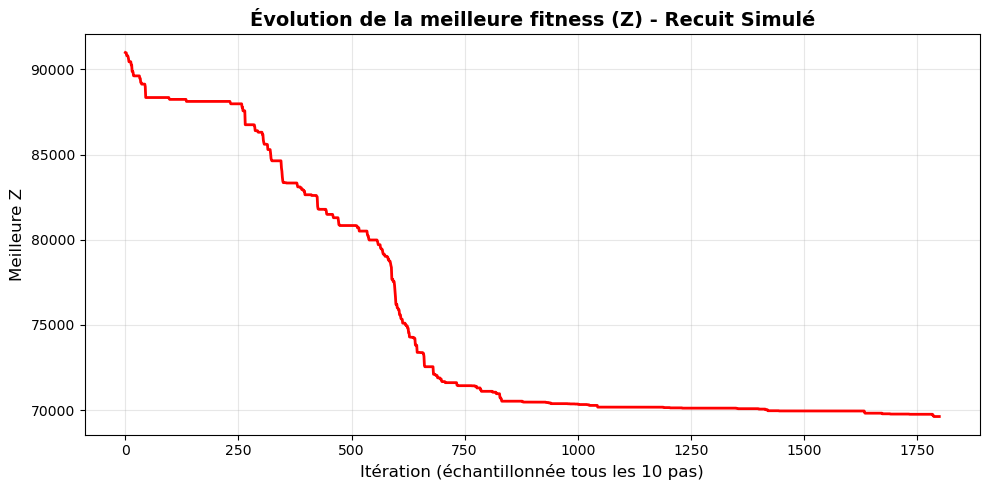

In [8]:
plt.figure(figsize=(10,5))
plt.plot(best_scores, linewidth=2, color='red')
plt.title("Évolution de la meilleure fitness (Z) - Recuit Simulé", fontsize=14, fontweight='bold')
plt.xlabel("Itération (échantillonnée tous les 10 pas)", fontsize=12)
plt.ylabel("Meilleure Z", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Export du nouveau planning

Si le recuit simulé a trouvé un meilleur planning que le planning initial, je l'exporte en Excel.

In [9]:
if Z_after < Z_initial:
    df_new_schedule = pd.DataFrame(0, index=df_conflict.index, columns=[f"Period_{t+1}" for t in range(P)])
    for i, per in enumerate(best_solution):
        df_new_schedule.iloc[i, int(per)] = 1
    out_path = "Res_RecuitSimule.xlsx"
    with pd.ExcelWriter(out_path) as writer:
        df_conflict.to_excel(writer, sheet_name="Conflict_Matrix")
        pd.DataFrame(w.reshape(1,-1), columns=[f"Period_{t+1}" for t in range(P)]).to_excel(writer, sheet_name="Weights", index=False)
        df_new_schedule.to_excel(writer, sheet_name="Schedule")
    print("Nouveau planning exporté vers:", out_path)
else:
    print("Aucune amélioration trouvée. Tu peux augmenter INITIAL_TEMP, réduire COOLING_RATE, ou augmenter ITERATIONS_PER_TEMP.")

Nouveau planning exporté vers: Res_RecuitSimule.xlsx


## 6. Conclusion

Ce projet m'a permis de comprendre en profondeur comment fonctionne une métaheuristique d'optimisation et dans quels cas elle est utile.

**Ce que j'ai compris sur le problème** : la planification d'examens est un problème NP-difficile. Pour N=100 examens et P=20 périodes, l'espace des solutions fait 20^100 combinaisons — il est impossible de toutes les tester. C'est là qu'interviennent les métaheuristiques comme le recuit simulé.

**Ce que j'ai appris sur le Recuit Simulé** : le paramétrage est crucial. Un COOLING_RATE trop élevé (refroidissement trop rapide) risque de faire converger trop tôt vers un minimum local. Un INITIAL_TEMP trop bas ne permet pas assez d'exploration. J'ai appris à lire la courbe de convergence pour diagnostiquer ces problèmes.

**Sur la complexité** : cet algorithme a une complexité temporelle en O(n² × T × I) où n est le nombre d'examens, T le nombre de paliers de température et I les itérations par palier. En pratique, il est beaucoup plus rapide que la recherche exhaustive et donne de bons résultats en quelques minutes.